<a href="https://colab.research.google.com/github/fadilaha/Ising-Model-on-Social-Opinion-Dynamic/blob/main/Ising_Model_with_Neutral_Opinion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

__ISING MODEL SIMULATION WITH NEUTRAL OPINION__  

The previous simulation shows the dynamic of binary opinion system consists of positive(+1) and negative(-1) sentiment on different temperature conditions. In this section, we add the presence of neutral opinion with its value equal to 0. Each spin act as an individual and contain one of these values: neutral, positive, or negative opinion. They may flip its stances using Glauber Scheme and Monte Carlo Simulation with the following rules:  
1. Neutral Spins can remain 0 or change to either 1 OR -1.
2. 1 AND -1 cannot change to 0.
3. If neutral spins flip attempt to negative or positive is accepted, they cannot change to 0 again.
4. For a flip attempt, 0 will randomly choose to remain neutral or change to +1 and -1. If the first choice is rejected by the Glauber Scheme, it will try another attempt for the next choice. It will stop until there is an accepted choice or no acceptance for all candidate, which led to no flip (remain 0).
The data used in this model is collected from our confidential daily opinion recap file. We use the data on August 1st 2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_glauber_with_data(N_up_initial, N_down_initial, N_o, T, h, J, q, steps):
# 1. INITIALIZATION
    N = N_up_initial + N_down_initial + N_o

    # Probability of each initial opinion
    P_up = N_up_initial / N
    P_down = N_down_initial / N
    P_neutral = N_o / N

    # Initial magnetization
    M_awal = (N_up_initial - N_down_initial) / N

    print("INITIAL SPIN CONDITION")
    print(f"Total Population (N) : {N}")
    print(f"Probability +1       : {P_up:.4f}")
    print(f"Probability -1       : {P_down:.4f}")
    print(f"Probability 0        : {P_neutral:.4f}")
    print(f"Initial M            : {M_awal:.4f}\n")

    # Assign spins according to observed initial counts
    spins = np.array([1] * N_up_initial + [-1] * N_down_initial + [0] * N_o)

    np.random.shuffle(spins)

    # Initial population counts
    N_up = np.sum(spins == 1)
    N_down = np.sum(spins == -1)
    N_neutral = np.sum(spins == 0)

    print("RANDOM ASSIGN SPIN CONDITION")
    print(f"N_up       : {N_up}")
    print(f"N_down     : {N_down}")
    print(f"N_neutral  : {N_neutral}")
    print(f"Actual M   : {(N_up - N_down) / N:.4f}\n")

# 2. GLAUBER + MEAN-FIELD SIMULATION
    magnetization_history = []
    N_up_history = []
    N_down_history = []
    N_neutral_history = []
    spin_history = []
    kB = 0.6

    spin_history.append(spins.copy())
    for step in range(steps):
        for _ in range(N):                   # N spin-update attempts = 1 Monte Carlo Step (MCS)
            M = (N_up - N_down) / N          # Current magnetization
            h_eff = h + J * q * M            # Mean-field effective field

            i = np.random.randint(0, N)      # Select random spin
            sigma_old = spins[i]

            # CASE 1: CURRENT SPIN = +1: +1 can stay +1 OR change to -1
            if sigma_old == 1:
                sigma_new = -1

                E_old = -sigma_old * h_eff   # Energy of old and new states
                E_new = -sigma_new * h_eff
                delta_E = E_new - E_old      # Energy Difference

                exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))  # Glauber probability
                P_transition = 1.0 / (1.0 + exp_term)

                r = np.random.rand()         # Accept/reject
                if r < P_transition:
                    sigma_final = -1
                else:
                    sigma_final = 1

            # CASE 2: CURRENT SPIN = -1: -1 can stay -1 OR change to +1
            elif sigma_old == -1:
                sigma_new = 1

                E_old = -sigma_old * h_eff   # Energy of old and new states
                E_new = -sigma_new * h_eff
                delta_E = E_new - E_old      # Energy Difference

                exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100))   # Glauber probability
                P_transition = 1.0 / (1.0 + exp_term)

                r = np.random.rand()         # Accept/reject
                if r < P_transition:
                    sigma_final = 1
                else:
                    sigma_final = -1

            # CASE 3: CURRENT SPIN = 0; Neutral can: 0 -> 0, 0 -> +1, 0 -> -1
            # Candidate states are tested in random order. The FIRST accepted candidate becomes the final state.
            else:
                candidates = [0, 1, -1]
                np.random.shuffle(candidates)       # Randomize candidate order
                sigma_final = 0                     # Default: remain neutral

                for sigma_new in candidates:        # Energy of old and candidate state
                    E_old = -sigma_old * h_eff
                    E_new = -sigma_new * h_eff
                    delta_E = E_new - E_old

                    exp_term = np.exp(np.clip(delta_E / (kB * T), -100, 100)) # Glauber probability
                    P_transition = 1.0 / (1.0 + exp_term)

                    r = np.random.rand()       # Accept/reject

                    if r < P_transition:

                        sigma_final = sigma_new
                        break

# 3. UPDATE POPULATION COUNTS
            if sigma_final != sigma_old:
                if sigma_old == 1:       # Remove old state
                    N_up -= 1
                elif sigma_old == -1:
                    N_down -= 1
                elif sigma_old == 0:
                    N_neutral -= 1

                if sigma_final == 1:     # Add new state
                    N_up += 1
                elif sigma_final == -1:
                    N_down += 1
                elif sigma_final == 0:
                    N_neutral += 1

                spins[i] = sigma_final    # Update spin

        # Store magnetization after one MCS
        M_current = (N_up - N_down) / N
        magnetization_history.append(M_current)
        N_up_history.append(N_up)
        N_down_history.append(N_down)
        N_neutral_history.append(N_neutral)
        spin_history.append(spins.copy())
    return (magnetization_history, N_up_history, N_down_history, N_neutral_history, spin_history)

# SIMULATION PARAMETERS
Data_N_up = 3130
Data_N_down = 1319
Data_N_neutral = 602
External_field = 0
J_coupling = 0.3
q_neighbors = 4.0
Time_steps = 200
Temperature = 2.0

# RUN SIMULATION
np.random.seed(42)
M_history, N_up_history, N_down_history, N_neutral_history, spin_history = simulate_glauber_with_data(N_up_initial=Data_N_up,
    N_down_initial=Data_N_down, N_o=Data_N_neutral, T=Temperature, h=External_field, J=J_coupling, q=q_neighbors, steps=Time_steps)


INITIAL SPIN CONDITION
Total Population (N) : 5051
Probability +1       : 0.6197
Probability -1       : 0.2611
Probability 0        : 0.1192
Initial M            : 0.3585

RANDOM ASSIGN SPIN CONDITION
N_up       : 3130
N_down     : 1319
N_neutral  : 602
Actual M   : 0.3585



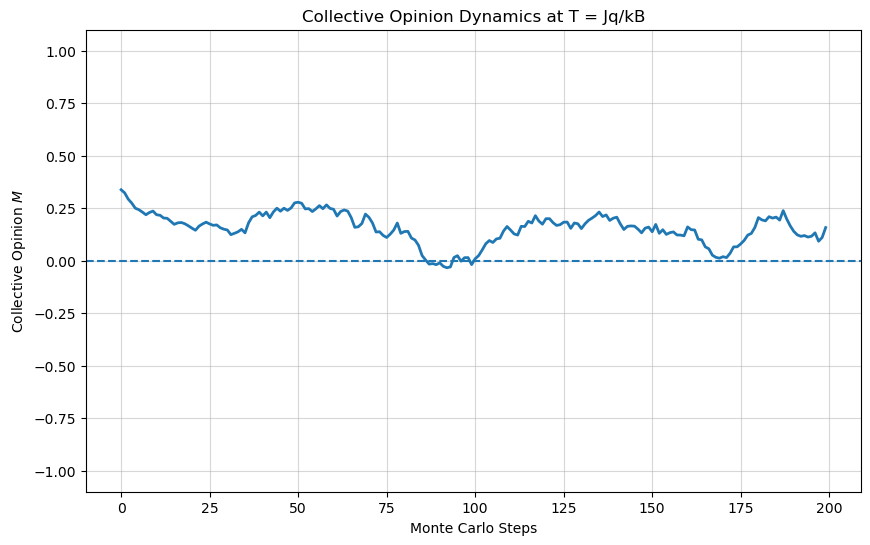

In [ ]:
#MAGNETIZATION AS COLLECTIVE OPINION PLOT
plt.figure(figsize=(10, 6))
plt.plot(M_history, linewidth=2)
plt.title("Collective Opinion Dynamics at T = Jq/kB")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Collective Opinion $M$")
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--')
plt.grid(True, alpha=0.5)
plt.show()

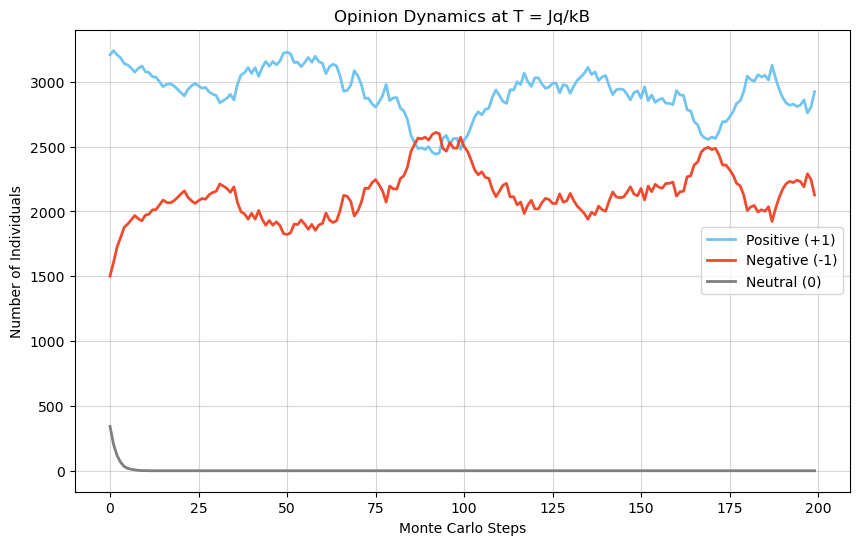

In [ ]:
#OPINION DYNAMIC PLOT
plt.figure(figsize=(10, 6))
plt.plot(N_up_history, linewidth=2, color="#72C5EF", label='Positive (+1)')
plt.plot(N_down_history, linewidth=2, color="#F04B2F", label='Negative (-1)')
plt.plot(N_neutral_history, linewidth=2, color="#7F7F7F", label='Neutral (0)')
plt.title("Opinion Dynamics at T = Jq/kB")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Number of Individuals")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [ ]:
Temperatures = [1, 2, 3]
M_T = {}
for T in Temperatures:
    np.random.seed(42)
    M_history_T, _, _, _,_ = simulate_glauber_with_data(N_up_initial=Data_N_up, N_down_initial=Data_N_down, N_o=Data_N_neutral,
        T=T, h=External_field, J=J_coupling, q=q_neighbors, steps=Time_steps)
    M_T[T] = M_history_T

INITIAL SPIN CONDITION
Total Population (N) : 5051
Probability +1       : 0.6197
Probability -1       : 0.2611
Probability 0        : 0.1192
Initial M            : 0.3585

RANDOM ASSIGN SPIN CONDITION
N_up       : 3130
N_down     : 1319
N_neutral  : 602
Actual M   : 0.3585

INITIAL SPIN CONDITION
Total Population (N) : 5051
Probability +1       : 0.6197
Probability -1       : 0.2611
Probability 0        : 0.1192
Initial M            : 0.3585

RANDOM ASSIGN SPIN CONDITION
N_up       : 3130
N_down     : 1319
N_neutral  : 602
Actual M   : 0.3585

INITIAL SPIN CONDITION
Total Population (N) : 5051
Probability +1       : 0.6197
Probability -1       : 0.2611
Probability 0        : 0.1192
Initial M            : 0.3585

RANDOM ASSIGN SPIN CONDITION
N_up       : 3130
N_down     : 1319
N_neutral  : 602
Actual M   : 0.3585



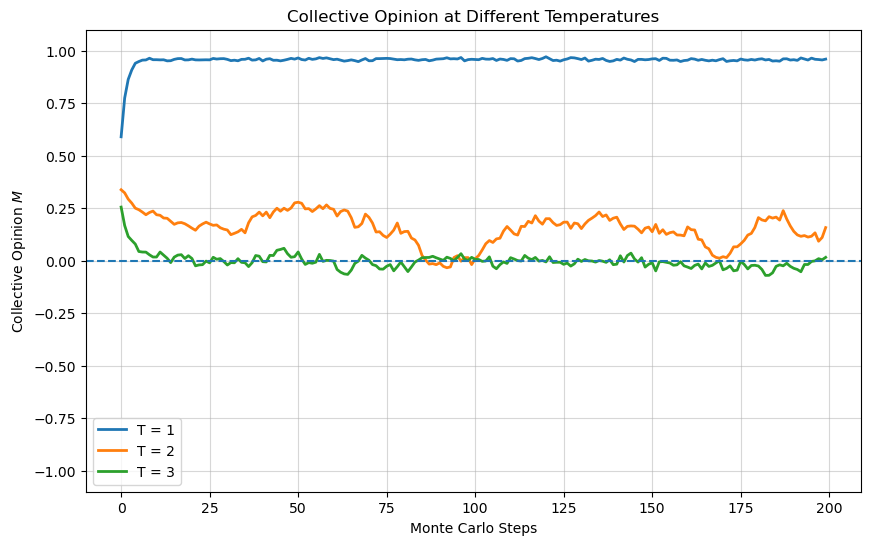

In [ ]:
plt.figure(figsize=(10, 6))

for T in Temperatures:
    plt.plot( M_T[T], linewidth=2, label=f"T = {T}")

plt.title("Collective Opinion at Different Temperatures")
plt.xlabel("Monte Carlo Steps")
plt.ylabel("Collective Opinion $M$")
plt.ylim(-1.1, 1.1)
plt.axhline(0, linestyle='--')
plt.legend()
plt.grid(True, alpha=0.5)

plt.show()

__SPATIAL VISUALIZATION MAP__

In [ ]:
from IPython.display import HTML, display
import json
import numpy as np

# Prepare data
spin_data = [np.asarray(s).tolist() for s in spin_history]

N = len(spin_data[0])
grid_size = int(np.ceil(np.sqrt(N)))

M_data = np.asarray(M_history).tolist()

# HTML + JavaScript
html = f"""
<div style="font-family: Arial; width: 650px;">

    <h3>Opinion Evolution</h3>

    <canvas id="opinionCanvas"
            width="600"
            height="600"
            style="border:1px solid black;">
    </canvas>

    <br><br>

    <input
        type="range"
        id="timeSlider"
        min="0"
        max="{len(spin_data)-1}"
        value="0"
        step="1"
        style="width:600px;"
    >

    <br><br>

    <button id="playButton">
        ▶ Play
    </button>

    <p>
        MCS:
        <span id="mcsValue">0</span>
        &nbsp;&nbsp;&nbsp;
        M:
        <span id="magValue">---</span>
    </p>

</div>

<script>

(function(){{

    const spinData = {json.dumps(spin_data)};
    const magnetization = {json.dumps(M_data)};

    const canvas = document.getElementById("opinionCanvas");
    const ctx = canvas.getContext("2d");

    const slider = document.getElementById("timeSlider");
    const playButton = document.getElementById("playButton");

    const mcsText = document.getElementById("mcsValue");
    const magText = document.getElementById("magValue");

    const N = {N};
    const gridSize = {grid_size};

    let playing = false;
    let animationTimer = null;

    // =========================
    // Draw map
    // =========================

    function drawMap(mcs) {{

        const spins = spinData[mcs];

        ctx.clearRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        ctx.fillStyle = "white";

        ctx.fillRect(
            0,
            0,
            canvas.width,
            canvas.height
        );

        const cellSize = canvas.width / gridSize;

        for (let i = 0; i < N; i++) {{

            const row = Math.floor(i / gridSize);
            const col = i % gridSize;

            const x = col * cellSize;
            const y = row * cellSize;

            const spin = spins[i];

            if (spin === 1) {{
                ctx.fillStyle = "red";
            }}
            else if (spin === -1) {{
                ctx.fillStyle = "blue";
            }}
            else {{
                ctx.fillStyle = "lightgray";
            }}

            ctx.fillRect(
                x,
                y,
                cellSize,
                cellSize
            );
        }}

        mcsText.textContent = mcs;

        if (mcs < magnetization.length) {{
            magText.textContent =
                magnetization[mcs].toFixed(4);
        }}
        else {{
            magText.textContent = "---";
        }}
    }}

    // =========================
    // Slider
    // =========================

    slider.addEventListener(
        "input",
        function() {{
            drawMap(parseInt(this.value));
        }}
    );

    // =========================
    // Play / Pause
    // =========================

    playButton.addEventListener(
        "click",
        function() {{

            if (playing) {{

                // Pause
                playing = false;

                clearInterval(animationTimer);

                playButton.textContent = "▶ Play";

            }} else {{

                // Play
                playing = true;

                playButton.textContent = "⏸ Pause";

                animationTimer = setInterval(
                    function() {{

                        let current =
                            parseInt(slider.value);

                        if (current >= spinData.length - 1) {{

                            // Stop at the end
                            playing = false;

                            clearInterval(animationTimer);

                            playButton.textContent = "▶ Play";

                            return;
                        }}

                        current += 1;

                        slider.value = current;

                        drawMap(current);

                    }},
                    100
                );
            }}
        }}
    );

    // =========================
    // Initial map
    // =========================

    drawMap(0);

}})();

</script>
"""

display(HTML(html))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# =========================
# PARAMETERS
# =========================
MCS = np.arange(1, len(M_history) + 1)

positive_color = "#73C5EF"
negative_color = "#F04B2F"
neutral_color  = "#7F7F7F"

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlim(0, len(M_history))
ax.set_ylim(-1, 1)

ax.set_xlabel("Monte Carlo Steps")
ax.set_ylabel("Collective Opinion M")
ax.set_title(r"Collective Opinion Dynamics at $T=Jq/k_B$")

ax.axhline(0, linestyle="--", linewidth=1)

line, = ax.plot([], [], linewidth=2, color=positive_color)

# Text showing current MCS
text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    verticalalignment="top"
)

def init():
    line.set_data([], [])
    text.set_text("")
    return line, text

def update(frame):
    x = MCS[:frame + 1]
    y = np.array(M_history[:frame + 1])

    line.set_data(x, y)

    text.set_text(
        f"MCS = {frame + 1}\n"
        f"M = {y[-1]:.3f}"
    )

    return line, text

ani = FuncAnimation(
    fig,
    update,
    frames=len(M_history),
    init_func=init,
    interval=50,
    blit=True
)

ani.save(
    "magnetization_dynamics.gif",
    writer=PillowWriter(fps=20)
)

plt.close(fig)

print("GIF magnetization berhasil dibuat!")

GIF magnetization berhasil dibuat!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter

# =========================
# PARAMETERS
# =========================
MCS = np.arange(1, len(N_up_history) + 1)

positive_color = "#73C5EF"
negative_color = "#F04B2F"
neutral_color  = "#7F7F7F"

# =========================
# FIGURE
# =========================
fig, ax = plt.subplots(figsize=(8, 5))

ax.set_xlim(0, len(N_up_history))

max_population = max(
    max(N_up_history),
    max(N_down_history),
    max(N_neutral_history)
)

ax.set_ylim(0, max_population * 1.1)

ax.set_xlabel("Monte Carlo Steps")
ax.set_ylabel("Number of Individuals")

ax.set_title(
    r"Opinion Dynamics at $T=Jq/k_B$"
)

# =========================
# EMPTY LINES
# =========================
line_positive, = ax.plot(
    [], [],
    linewidth=2,
    color=positive_color,
    label="Positive (+1)"
)

line_negative, = ax.plot(
    [], [],
    linewidth=2,
    color=negative_color,
    label="Negative (-1)"
)

line_neutral, = ax.plot(
    [], [],
    linewidth=2,
    color=neutral_color,
    label="Neutral (0)"
)

ax.legend()

# =========================
# MCS TEXT
# =========================
text = ax.text(
    0.02, 0.95, "",
    transform=ax.transAxes,
    verticalalignment="top"
)

# =========================
# INITIALIZATION
# =========================
def init():
    line_positive.set_data([], [])
    line_negative.set_data([], [])
    line_neutral.set_data([], [])
    text.set_text("")

    return (
        line_positive,
        line_negative,
        line_neutral,
        text
    )

# =========================
# ANIMATION
# =========================
def update(frame):

    x = MCS[:frame + 1]

    line_positive.set_data(
        x,
        N_up_history[:frame + 1]
    )

    line_negative.set_data(
        x,
        N_down_history[:frame + 1]
    )

    line_neutral.set_data(
        x,
        N_neutral_history[:frame + 1]
    )

    text.set_text(
        f"MCS = {frame + 1}"
    )

    return (
        line_positive,
        line_negative,
        line_neutral,
        text
    )

ani = FuncAnimation(
    fig,
    update,
    frames=len(N_up_history),
    init_func=init,
    interval=50,
    blit=True
)

ani.save(
    "opinion_population_dynamics.gif",
    writer=PillowWriter(fps=20)
)

plt.close(fig)

print("GIF opinion population berhasil dibuat!")

GIF opinion population berhasil dibuat!


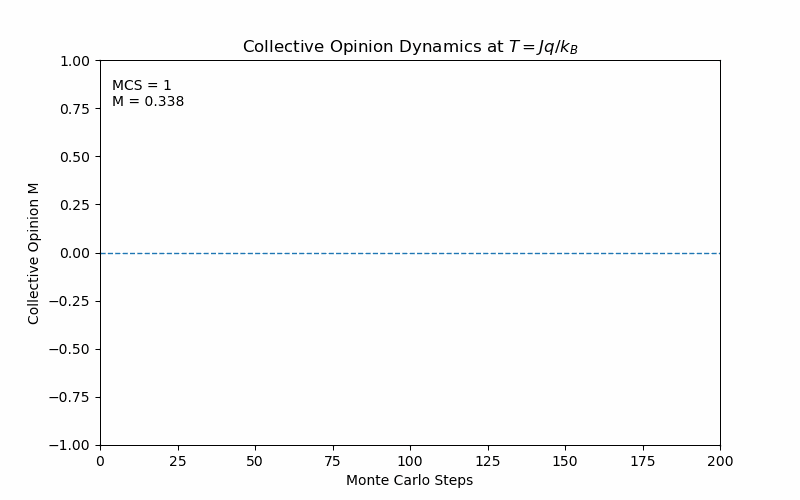

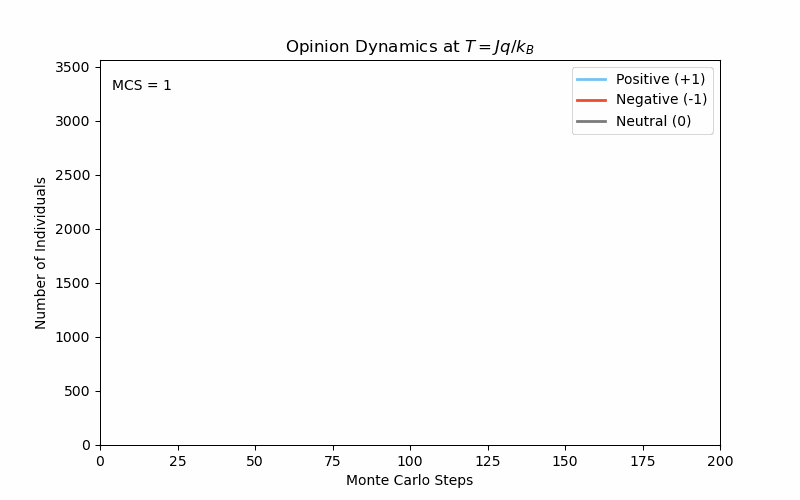

In [ ]:
from IPython.display import Image, display

display(Image(filename=r"C:\Users\HP\magnetization_dynamics.gif"))
display(Image(filename=r"C:\Users\HP\opinion_population_dynamics.gif"))